# EDA for Insurance Cost Predictor
### Author: Ruide Yin

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Shape: (1338, 7)

Dtypes:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 1. Univariate Distributions

### 1.1 Numerical Features

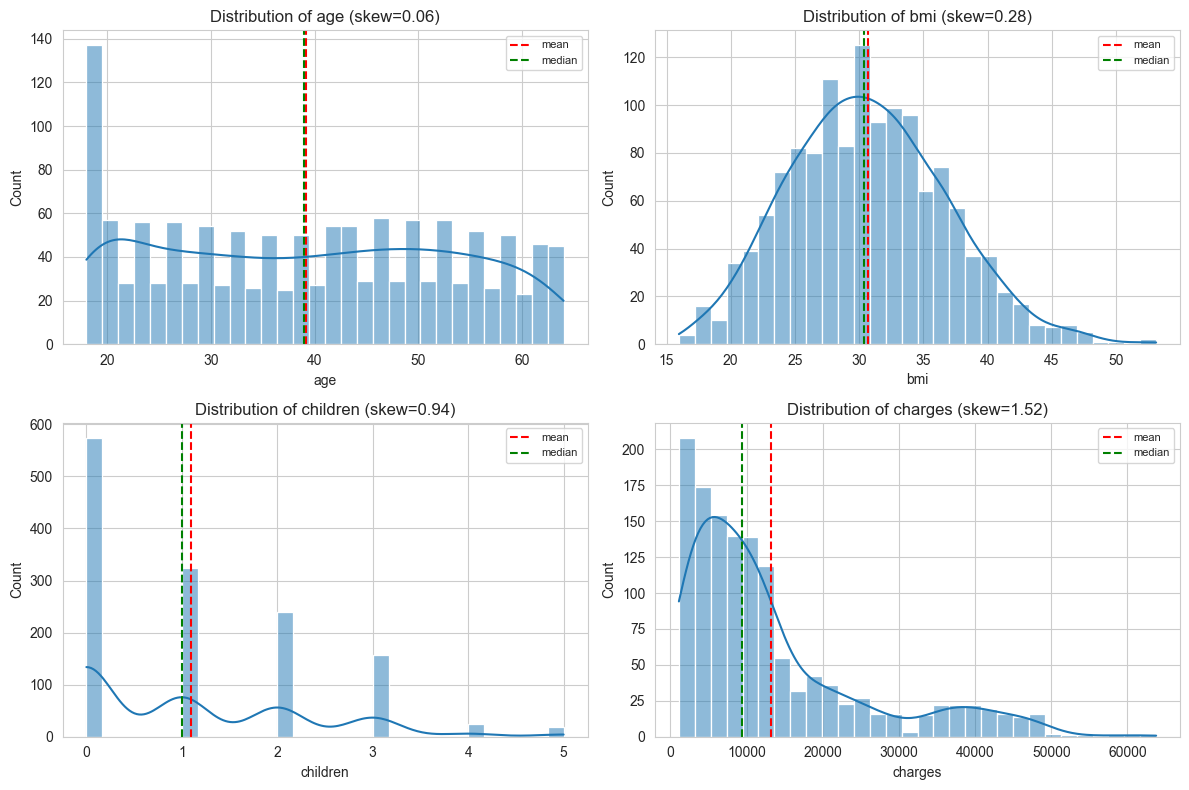

In [5]:
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax, edgecolor='white')
    skew_val = df[col].skew()
    ax.set_title(f"Distribution of {col} (skew={skew_val:.2f})")
    ax.axvline(df[col].mean(), color='red', linestyle='--', label='mean')
    ax.axvline(df[col].median(), color='green', linestyle='--', label='median')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

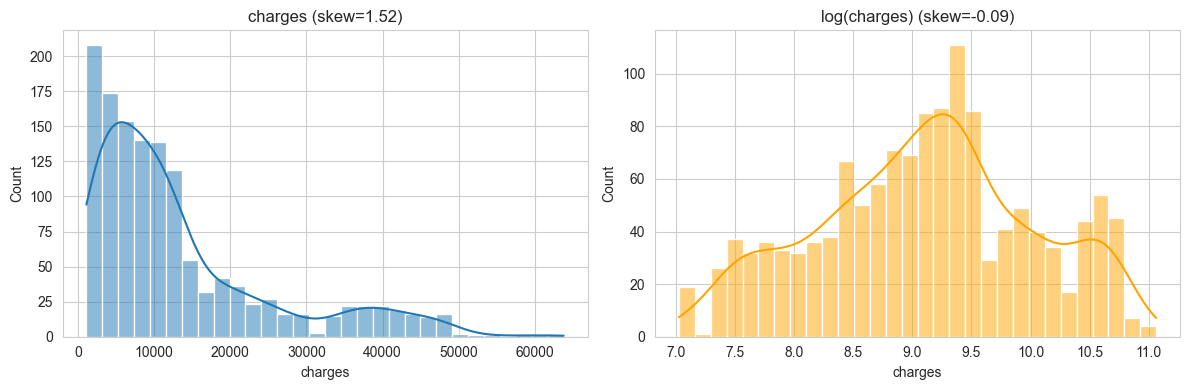

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].set_title(f"charges (skew={df['charges'].skew():.2f})")
sns.histplot(df['charges'], kde=True, bins=30, ax=axes[0], edgecolor='white')

log_charges = np.log1p(df['charges'])
axes[1].set_title(f"log(charges) (skew={log_charges.skew():.2f})")
sns.histplot(log_charges, kde=True, bins=30, ax=axes[1], edgecolor='white', color='orange')

plt.tight_layout()
plt.show()

Log transformation significantly reduces the right skew of charges, suggesting that models like Linear Regression may benefit from predicting on the log-transformed target.

### 1.2 Categorical Features

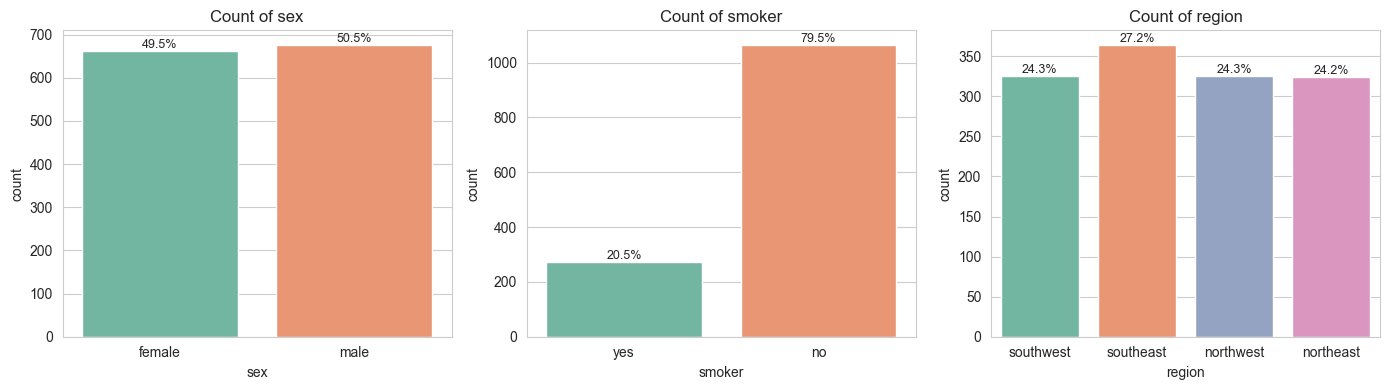

In [7]:
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    sns.countplot(data=df, x=col, palette='Set2', ax=ax, edgecolor='white')
    ax.set_title(f"Count of {col}")
    # annotate percentages
    total = len(df)
    for p in ax.patches:
        pct = f"{100 * p.get_height() / total:.1f}%"
        ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Sex and region are roughly balanced. Smoker is imbalanced (~20% yes vs ~80% no), but this reflects real-world prevalence and does not require oversampling for regression tasks.

## 2. Bivariate Relationships

### 2.1 Each Feature vs Charges

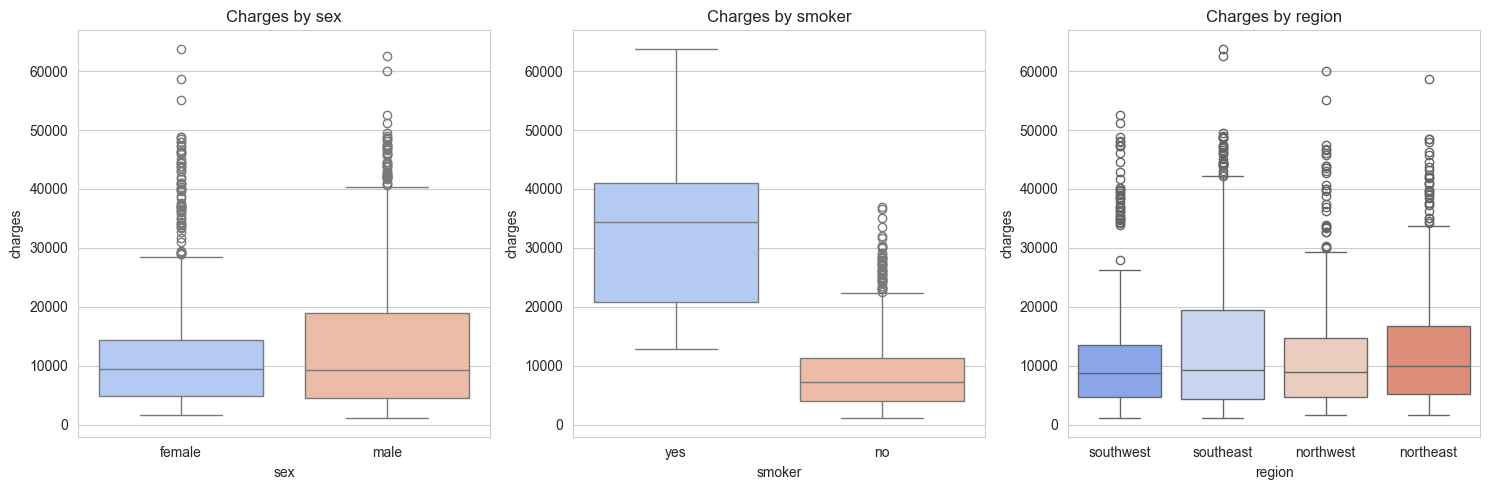

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y='charges', palette='coolwarm', ax=ax)
    ax.set_title(f"Charges by {col}")

plt.tight_layout()
plt.show()

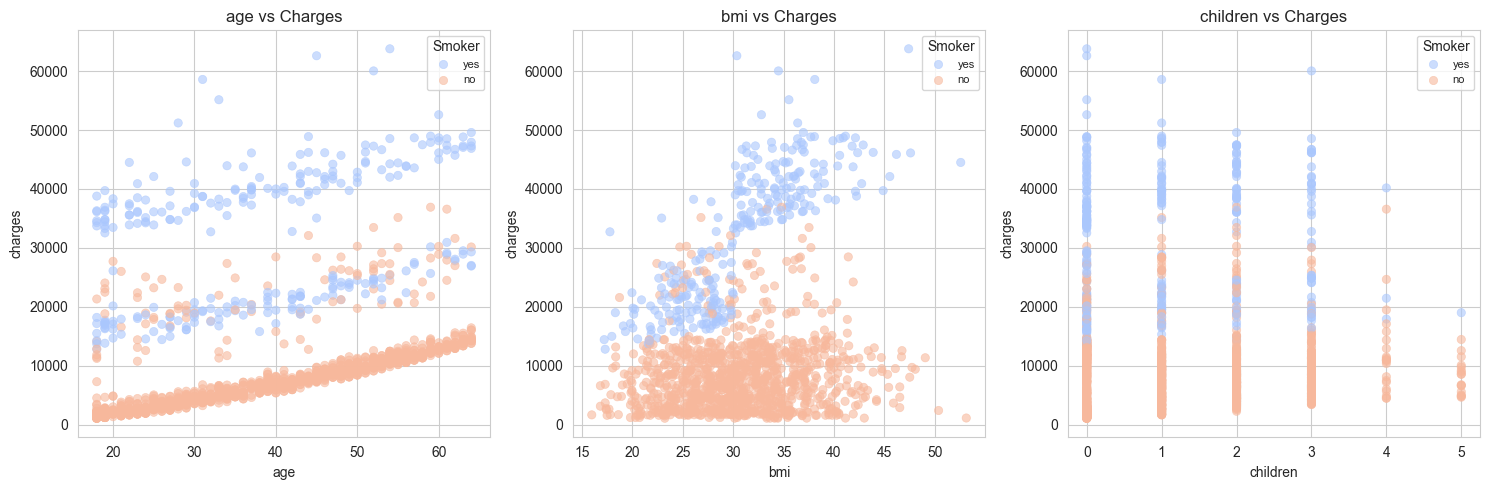

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
scatter_cols = ['age', 'bmi', 'children']

for ax, col in zip(axes, scatter_cols):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker',
                    palette='coolwarm', alpha=0.6, ax=ax, edgecolor=None)
    ax.set_title(f"{col} vs Charges")
    ax.legend(title='Smoker', fontsize=8)

plt.tight_layout()
plt.show()

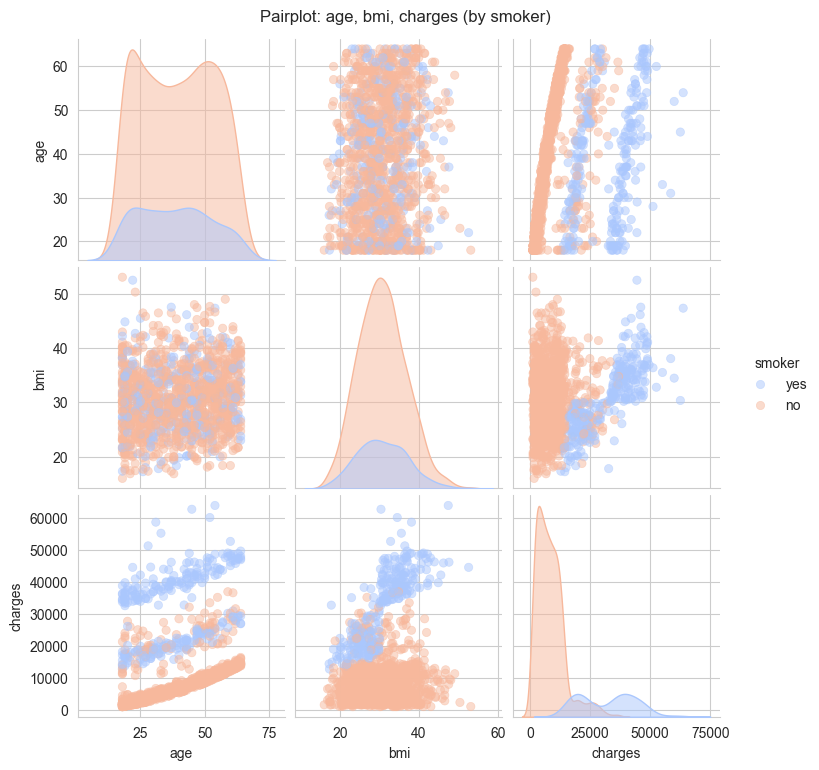

In [10]:
sns.pairplot(df[['age', 'bmi', 'charges', 'smoker']],
             hue='smoker', palette='coolwarm',
             plot_kws={'alpha': 0.5, 'edgecolor': None},
             diag_kws={'alpha': 0.5})
plt.suptitle("Pairplot: age, bmi, charges (by smoker)", y=1.02)
plt.show()

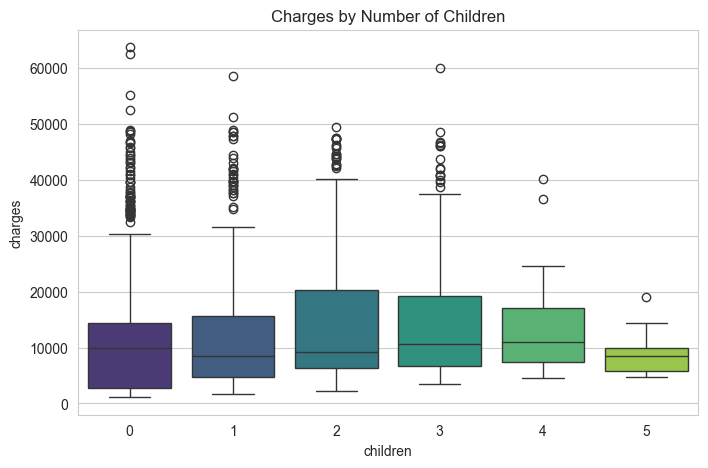

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='children', y='charges', palette='viridis', ax=ax)
ax.set_title("Charges by Number of Children")
plt.show()

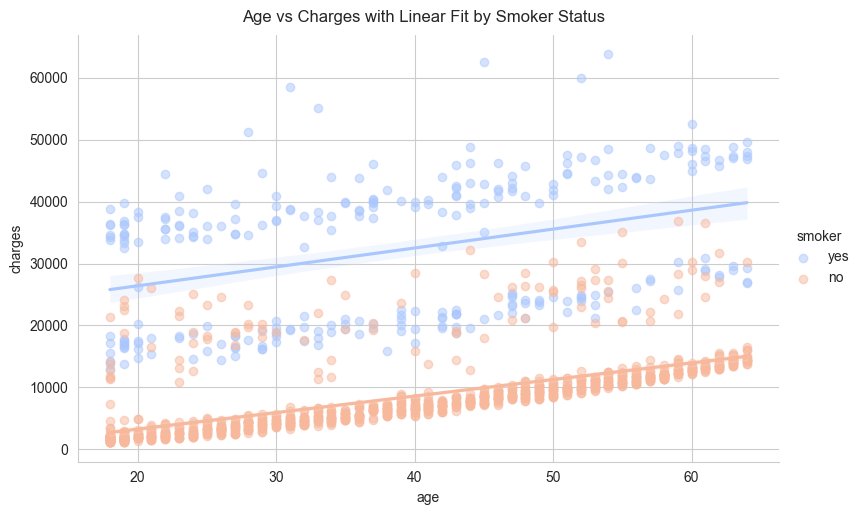

In [12]:
g = sns.lmplot(data=df, x='age', y='charges', hue='smoker',
               palette='coolwarm', height=5, aspect=1.6,
               scatter_kws={'alpha': 0.5, 'edgecolor': None})
g.figure.suptitle("Age vs Charges with Linear Fit by Smoker Status", y=1.02)
plt.show()

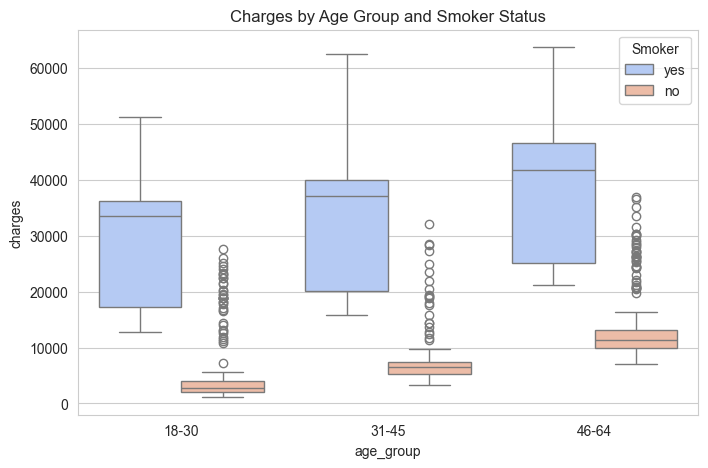

In [13]:
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 64],
                         labels=['18-30', '31-45', '46-64'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='age_group', y='charges', hue='smoker',
            palette='coolwarm', ax=ax)
ax.set_title("Charges by Age Group and Smoker Status")
ax.legend(title='Smoker')
plt.show()

df.drop(columns=['age_group'], inplace=True)

In [14]:
for status in ['yes', 'no']:
    subset = df[df['smoker'] == status]
    r, p = stats.pearsonr(subset['bmi'], subset['charges'])
    print(f"Smoker={status}: BMI–Charges Pearson r = {r:.3f}, p = {p:.2e}")

Smoker=yes: BMI–Charges Pearson r = 0.806, p = 5.02e-64
Smoker=no: BMI–Charges Pearson r = 0.084, p = 6.09e-03


Key observations:

- **Smoker** is the dominant driver of charges, creating a clear bimodal split.
- **Age** shows a positive linear trend with charges, with smokers forming a distinct upper band. The lmplot confirms both groups have similar positive slopes but vastly different intercepts.
- **BMI** has a weak overall correlation with charges, but among smokers, higher BMI is strongly associated with higher charges (r ≈ 0.81 vs r ≈ 0.08 for non-smokers) — an interaction effect that Pearson correlation alone cannot capture.
- **Sex** and **region** show minimal impact on charges.

### 2.2 Correlation Matrix

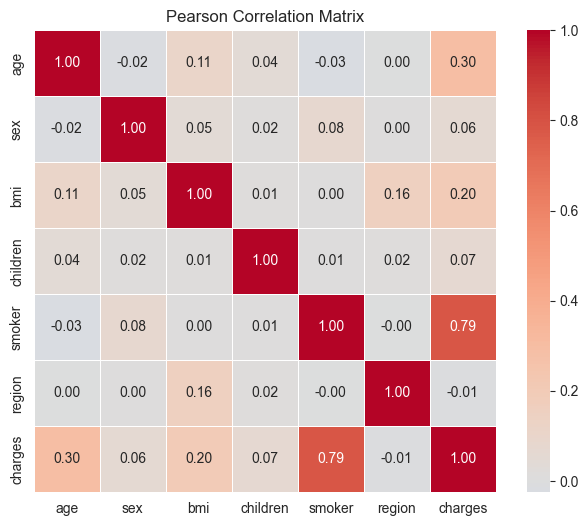

In [15]:
# Encode categoricals for correlation
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded['region'] = df_encoded['region'].map({
    'northeast': 1, 'northwest': 2, 'southeast': 3, 'southwest': 4
})

corr = df_encoded.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

Pearson correlation shows smoker (0.79) and age (0.30) as the strongest linear correlates of charges. However, Pearson underestimates the BMI–charges relationship because it is conditional on smoker status (interaction effect). This motivates the Block 2 stratified modeling approach.

### 2.3 Smoker vs Non-Smoker Charge Distributions

In [16]:
print(df.groupby('smoker')['charges'].describe().round(2).to_string())

         count      mean       std       min       25%       50%       75%       max
smoker                                                                              
no      1064.0   8434.27   5993.78   1121.87   3986.44   7345.41  11362.89  36910.61
yes      274.0  32050.23  11541.55  12829.46  20826.24  34456.35  41019.21  63770.43


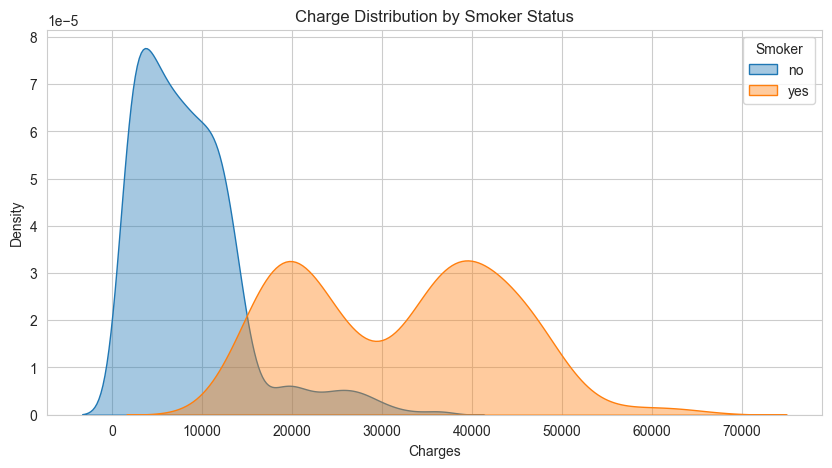

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in df.groupby('smoker'):
    sns.kdeplot(group['charges'], label=label, fill=True, alpha=0.4, ax=ax)
ax.set_title("Charge Distribution by Smoker Status")
ax.set_xlabel("Charges")
ax.legend(title="Smoker")
plt.show()

The two groups have near-disjoint distributions, confirming that modeling them separately (Block 2) is well-motivated. Non-smokers have a mean of ~$8,434 (median ~$7,345), while smokers average ~$32,050 (median ~$34,456). The non-smoker distribution is unimodal and right-skewed; the smoker distribution is broader with higher variance.

## 3. Outlier Detection

In [18]:
def iqr_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: {len(outliers)} outliers ({100*len(outliers)/len(series):.1f}%) "
          f"| range [{lower:.2f}, {upper:.2f}]")
    return outliers

print("=== IQR-based Outlier Detection ===\n")
for col in ['charges', 'bmi']:
    iqr_outliers(df[col], col)

=== IQR-based Outlier Detection ===

charges: 139 outliers (10.4%) | range [-13109.15, 34489.35]
bmi: 9 outliers (0.7%) | range [13.70, 47.29]


BMI outliers are plausible real-world values (high BMI is common). Charges outliers correspond to high-cost smoker cases — these are genuine data points, not errors. **Decision: retain all outliers.**

## 4. Statistical Tests

In [19]:
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

# Welch's t-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)
print(f"Welch's t-test: t={t_stat:.2f}, p={p_val:.2e}")

# Effect size (Cohen's d)
pooled_std = np.sqrt((smoker_charges.std()**2 + nonsmoker_charges.std()**2) / 2)
cohens_d = (smoker_charges.mean() - nonsmoker_charges.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.2f}")

print(f"\nSmoker mean:     ${smoker_charges.mean():,.2f}")
print(f"Non-smoker mean: ${nonsmoker_charges.mean():,.2f}")

Welch's t-test: t=32.75, p=5.89e-103
Cohen's d: 2.57

Smoker mean:     $32,050.23
Non-smoker mean: $8,434.27


In [20]:
# One-way ANOVA: region
region_groups = [group['charges'].values for _, group in df.groupby('region')]
f_region, p_region = stats.f_oneway(*region_groups)
print(f"ANOVA (region → charges): F={f_region:.2f}, p={p_region:.4f}")

# t-test: sex
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']
t_sex, p_sex = stats.ttest_ind(male_charges, female_charges, equal_var=False)
print(f"Welch's t-test (sex → charges): t={t_sex:.2f}, p={p_sex:.4f}")

ANOVA (region → charges): F=2.97, p=0.0309
Welch's t-test (sex → charges): t=2.10, p=0.0358


- The smoker vs non-smoker difference is overwhelmingly significant (p ≈ 0) with a very large effect size (Cohen's d ≈ 2.57), confirming that smoker status is the single most important predictor.
- Region shows a statistically significant effect (p = 0.031), but the F-statistic is small (F = 2.97), suggesting the practical impact on charges is minimal. We retain region as a feature but do not expect it to be a strong predictor.
- Sex shows a marginally significant effect (p = 0.036), similarly with limited practical importance.

## 5. Multicollinearity Check

In [21]:
X = df_encoded.drop(columns=['charges'])
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))

 Feature       VIF
     bmi 12.330416
     age  7.611260
  region  5.925718
     sex  2.002921
children  1.803916
  smoker  1.257231


Most VIF values are moderate (sex, children, smoker all below 3). However, BMI (VIF ≈ 12.3), age (VIF ≈ 7.6), and region (VIF ≈ 5.9) are elevated — likely inflated by the ordinal encoding of region, which introduces a spurious linear scale. For tree-based and neural network models this is not a concern. For Linear Regression, we use one-hot encoding for region to avoid artificial collinearity, and monitor coefficient stability.

## 6. Key Findings Summary

1. **No data quality issues**: no missing values, 1 duplicate row (retained — likely a distinct individual with identical features). All outliers are genuine.
2. **Charges distribution is bimodal**, driven by smoker status. Log transformation reduces skew for linear models.
3. **Smoker is the dominant predictor** (Pearson r ≈ 0.79, Cohen's d ≈ 2.57, p ≈ 0). This motivates the Block 2 stratified pipeline.
4. **BMI × smoker interaction**: BMI matters significantly for smokers (r ≈ 0.81) but minimally for non-smokers (r ≈ 0.08). Pearson correlation alone misses this.
5. **Age** has a moderate positive effect on charges across both groups.
6. **Sex and region** are statistically significant (p < 0.05) but have small effect sizes — they are retained as features but not expected to be strong predictors.
7. **Multicollinearity**: BMI and age show elevated VIF under ordinal encoding of region; one-hot encoding and tree-based models mitigate this.

### Implications for preprocessing:
- Log-transform charges for models that assume normality (Linear Regression).
- Encode categoricals (one-hot for Linear Regression; label encoding acceptable for tree-based models).
- No need for imputation or outlier removal.
- Smoker stratification is statistically justified for Block 2.